# First-Layer Feature Maps: L1 vs Feature-Map Pruning

This notebook visualizes first-layer feature maps in a channel grid and overlays pruning decisions:

- **Red border**: pruned by L1 norm pruning
- **Blue border**: pruned by feature-map pruning (e.g. correlation mask)
- **Double border (red outer + blue inner)**: pruned by both

Each tile also shows the **channel index**.

In [1]:
from pathlib import Path
import os
import random
import json
import sys

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.patheffects as path_effects
import numpy as np
import torch
import torch.nn.functional as F

PROJECT_ROOT = Path('/mnt/hdd/ttoxopeus/basic_UNet')
SRC_ROOT = PROJECT_ROOT / 'src'

# Add project root so `import src....` works
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Also add src root as fallback for `import training....` style imports
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

try:
    from src.training.data_loader import SegmentationDataset
except ModuleNotFoundError:
    from training.data_loader import SegmentationDataset


/media/ttoxopeus/miniconda3/envs/nnunet/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ---- Configure run directories (same style as compare_masks.ipynb) ----
l1_run_dir = Path('/mnt/hdd/ttoxopeus/basic_UNet/results/UNet_ACDC/exp78_compare_methods/pruned/l1_norm_25_25_25_25_25_25_25_25_25_25_25')
fm_run_dir = Path('/mnt/hdd/ttoxopeus/basic_UNet/results/UNet_ACDC/exp78_compare_methods/pruned/corr_t85_25_25_25_25_25_25_25_25_25_25_25')

# Layer to visualize
layer_name = 'encoders.0.net.0'

# Grid options
num_cols = 8
normalize_each_channel = True


In [3]:
def resolve_mask_path(run_dir: Path, filenames):
    candidates = []
    for name in filenames:
        candidates.extend([
            run_dir / 'pruned_model' / name,
            run_dir / 'pruned' / name,
            run_dir / 'masks' / name,
            run_dir / name,
        ])
    for c in candidates:
        if c.exists():
            return c
    raise FileNotFoundError(f'Could not find any of {filenames} in {run_dir}')


def load_run_summary(run_dir: Path) -> dict:
    p1 = run_dir / 'run_summary.json'
    p2 = run_dir / 'pruned_model' / 'run_summary.json'
    path = p1 if p1.exists() else p2
    if not path.exists():
        raise FileNotFoundError(f'Missing run_summary.json in {run_dir}')
    return json.loads(path.read_text())


def unwrap_state_dict(obj):
    if isinstance(obj, dict):
        for k in ['state_dict', 'model_state_dict', 'net', 'model']:
            if k in obj and isinstance(obj[k], dict):
                return obj[k]
    return obj


def get_key(sd: dict, key: str) -> str:
    if key in sd:
        return key
    prefixed = f'module.{key}'
    if prefixed in sd:
        return prefixed
    raise KeyError(f'Missing key {key} (and module.{key})')


In [4]:
# ---- Load masks ----
l1_mask_path = resolve_mask_path(l1_run_dir, ['l1_masks.pt'])
fm_mask_path = resolve_mask_path(fm_run_dir, ['correlation_masks.pt', 'feature_map_masks.pt', 'redundancy_masks.pt'])

l1_masks = torch.load(l1_mask_path, map_location='cpu')
fm_masks = torch.load(fm_mask_path, map_location='cpu')

if layer_name not in l1_masks:
    raise KeyError(f'{layer_name} not in L1 masks. Example keys: {list(l1_masks.keys())[:10]}')
if layer_name not in fm_masks:
    raise KeyError(f'{layer_name} not in feature-map masks. Example keys: {list(fm_masks.keys())[:10]}')

l1_keep = l1_masks[layer_name].detach().cpu().bool()
fm_keep = fm_masks[layer_name].detach().cpu().bool()

if l1_keep.shape != fm_keep.shape:
    raise ValueError(f'Mask shape mismatch: L1={tuple(l1_keep.shape)} vs FM={tuple(fm_keep.shape)}')

num_channels = int(l1_keep.numel())
print('L1 mask:', l1_mask_path)
print('Feature-map mask:', fm_mask_path)
print('Layer:', layer_name)
print('Channels:', num_channels)
print(f'L1 pruned: {(~l1_keep).sum().item()} / {num_channels}')
print(f'FM pruned: {(~fm_keep).sum().item()} / {num_channels}')
print(f'Pruned by both: {((~l1_keep) & (~fm_keep)).sum().item()} / {num_channels}')

L1 mask: /mnt/hdd/ttoxopeus/basic_UNet/results/UNet_ACDC/exp78_compare_methods/pruned/l1_norm_25_25_25_25_25_25_25_25_25_25_25/pruned_model/l1_masks.pt
Feature-map mask: /mnt/hdd/ttoxopeus/basic_UNet/results/UNet_ACDC/exp78_compare_methods/pruned/corr_t85_25_25_25_25_25_25_25_25_25_25_25/pruned_model/correlation_masks.pt
Layer: encoders.0.net.0
Channels: 64
L1 pruned: 16 / 64
FM pruned: 16 / 64
Pruned by both: 2 / 64


In [5]:
# ---- Build first-layer feature maps from baseline checkpoint ----
summary = load_run_summary(l1_run_dir)
baseline_ckpt_path = Path(summary['prune']['checkpoints']['baseline_ckpt'])
baseline_obj = torch.load(baseline_ckpt_path, map_location='cpu')
baseline_sd = unwrap_state_dict(baseline_obj)

weight_name = get_key(baseline_sd, f'{layer_name}.weight')
bias_name = None
try:
    bias_name = get_key(baseline_sd, f'{layer_name}.bias')
except KeyError:
    pass

weight = baseline_sd[weight_name].detach().cpu().float()
bias = baseline_sd[bias_name].detach().cpu().float() if bias_name is not None else None

if weight.shape[0] != num_channels:
    raise ValueError(
        f'First-layer out channels ({weight.shape[0]}) do not match masks ({num_channels}). '
        'Check that run dirs and layer_name refer to the same model version.'
    )

if 'input_tensor' in globals():
    x = input_tensor.detach().cpu().float()
    print('Using input_tensor from notebook globals with shape:', tuple(x.shape))
else:
    in_ch = int(weight.shape[1])
    x = torch.randn(1, in_ch, 256, 256)
    print('No input_tensor found. Using random tensor with shape:', tuple(x.shape))

if x.ndim != 4:
    raise ValueError(f'input tensor must be NCHW (4D), got shape {tuple(x.shape)}')
if x.shape[0] != 1:
    x = x[:1]
if x.shape[1] != weight.shape[1]:
    raise ValueError(f'Input channels ({x.shape[1]}) must match first-layer in channels ({weight.shape[1]})')

feature_maps = F.conv2d(x, weight, bias=bias, stride=1, padding=1)
print('Baseline checkpoint:', baseline_ckpt_path)
print('Feature maps shape:', tuple(feature_maps.shape))

No input_tensor found. Using random tensor with shape: (1, 1, 256, 256)
Baseline checkpoint: /mnt/hdd/ttoxopeus/basic_UNet/results/UNet_ACDC/exp78_compare_methods/baseline/training/final_model.pth
Feature maps shape: (1, 64, 256, 256)


In [6]:
# ---- Build first-layer feature maps from baseline checkpoint ----
summary = load_run_summary(l1_run_dir)
baseline_ckpt_path = Path(summary['prune']['checkpoints']['baseline_ckpt'])
baseline_obj = torch.load(baseline_ckpt_path, map_location='cpu')
baseline_sd = unwrap_state_dict(baseline_obj)

weight_name = get_key(baseline_sd, f'{layer_name}.weight')
bias_name = None
try:
    bias_name = get_key(baseline_sd, f'{layer_name}.bias')
except KeyError:
    pass

weight = baseline_sd[weight_name].detach().cpu().float()
bias = baseline_sd[bias_name].detach().cpu().float() if bias_name is not None else None

if weight.shape[0] != num_channels:
    raise ValueError(
        f'First-layer out channels ({weight.shape[0]}) do not match masks ({num_channels}). '
        'Check that run dirs and layer_name refer to the same model version.'
    )

# Data loading settings (same pattern as inspect_augmentation.ipynb)
IMG_DIR = '/media/ttoxopeus/datasets/nnUNet_raw/Dataset200_ACDC/imagesTr'
LBL_DIR = '/media/ttoxopeus/datasets/nnUNet_raw/Dataset200_ACDC/labelsTr'
TARGET_SIZE = (256, 256)
NUM_SLICES_PER_VOLUME = 30
SLICE_AXIS = 2
SAMPLE_INDEX = 0  # change if you want another slice

if 'input_tensor' in globals():
    x = input_tensor.detach().cpu().float()
    print('Using input_tensor from notebook globals with shape:', tuple(x.shape))
else:
    img_dir = Path(IMG_DIR)
    lbl_dir = Path(LBL_DIR)

    if img_dir.exists() and lbl_dir.exists():
        img_paths = sorted([str(p) for p in img_dir.glob('*.nii.gz')])
        lbl_paths = sorted([str(p) for p in lbl_dir.glob('*.nii.gz')])
        pairs = list(zip(img_paths, lbl_paths))

        if not pairs:
            raise RuntimeError(f'No image/label pairs found in {IMG_DIR} / {LBL_DIR}')

        ds = SegmentationDataset(
            pairs,
            slice_axis=SLICE_AXIS,
            normalize=True,
            target_size=TARGET_SIZE,
            augment=False,
            num_slices_per_volume=NUM_SLICES_PER_VOLUME,
            use_cache=False,
        )

        sample_idx = min(SAMPLE_INDEX, len(ds) - 1)
        img, _ = ds[sample_idx]          # img: [1, H, W] tensor
        x = img.unsqueeze(0).detach().cpu().float()  # [1, 1, H, W]
        print(f'Loaded real sample from SegmentationDataset (idx={sample_idx}) with shape:', tuple(x.shape))
    else:
        in_ch = int(weight.shape[1])
        x = torch.randn(1, in_ch, 256, 256)
        print('Dataset paths not found. Using random tensor with shape:', tuple(x.shape))

if x.ndim != 4:
    raise ValueError(f'input tensor must be NCHW (4D), got shape {tuple(x.shape)}')
if x.shape[0] != 1:
    x = x[:1]
if x.shape[1] != weight.shape[1]:
    raise ValueError(f'Input channels ({x.shape[1]}) must match first-layer in channels ({weight.shape[1]})')

feature_maps = F.conv2d(x, weight, bias=bias, stride=1, padding=1)
print('Baseline checkpoint:', baseline_ckpt_path)
print('Feature maps shape:', tuple(feature_maps.shape))


Loaded real sample from SegmentationDataset (idx=0) with shape: (1, 1, 256, 256)
Baseline checkpoint: /mnt/hdd/ttoxopeus/basic_UNet/results/UNet_ACDC/exp78_compare_methods/baseline/training/final_model.pth
Feature maps shape: (1, 64, 256, 256)


In [7]:
def plot_first_layer_grid(feature_maps, l1_keep, fm_keep, num_cols=8, normalize=True):
    fmap = feature_maps[0].detach().cpu()  # [C, H, W]
    C_total = fmap.shape[0]

    # Force a true 8x8 grid (64 tiles).
    grid_size = 8
    max_tiles = grid_size * grid_size
    C_show = min(C_total, max_tiles)

    fig, axes = plt.subplots(grid_size, grid_size, figsize=(grid_size * 2.05, grid_size * 2.05), dpi=140)
    axes = np.atleast_1d(axes).reshape(grid_size, grid_size)

    for i, ax in enumerate(axes.flatten()):
        ax.axis('off')
        if i >= C_show:
            continue

        img = fmap[i]
        if normalize:
            mn = float(img.min())
            mx = float(img.max())
            if mx > mn:
                img = (img - mn) / (mx - mn)

        ax.imshow(img, cmap='gray', interpolation='nearest')

        # Channel index (high-contrast label for readability)
        ax.text(
            0.03, 0.05, f'ch {i}',
            color='white', fontsize=12, fontweight='bold',
            ha='left', va='top', transform=ax.transAxes,
            bbox=dict(boxstyle='round,pad=0.20', facecolor='black', edgecolor='white', linewidth=1.0, alpha=0.80),
            zorder=30,
        )

        l1_pruned = bool(~l1_keep[i])
        fm_pruned = bool(~fm_keep[i])

        if l1_pruned and fm_pruned:
            # Outer red + inner blue
            ax.add_patch(patches.Rectangle((0, 0), 1, 1, fill=False, edgecolor='red', linewidth=4.5, transform=ax.transAxes, zorder=10))
            ax.add_patch(patches.Rectangle((0.060, 0.060), 0.88, 0.88, fill=False, edgecolor='royalblue', linewidth=4.5, transform=ax.transAxes, zorder=11))
        elif l1_pruned:
            ax.add_patch(patches.Rectangle((0, 0), 1, 1, fill=False, edgecolor='red', linewidth=4.5, transform=ax.transAxes, zorder=10))
        elif fm_pruned:
            ax.add_patch(patches.Rectangle((0, 0), 1, 1, fill=False, edgecolor='royalblue', linewidth=4.5, transform=ax.transAxes, zorder=10))

    legend_handles = [
        patches.Patch(facecolor='none', edgecolor='red', linewidth=4, label='Pruned by L1'),
        patches.Patch(facecolor='none', edgecolor='royalblue', linewidth=4, label='Pruned by feature-map method'),
    ]

    fig.suptitle(f'First-layer feature maps with pruning overlays ({layer_name})', fontsize=26, y=0.995)
    fig.legend(handles=legend_handles, loc='upper center', ncol=2, frameon=False, bbox_to_anchor=(0.5, 0.968), prop={'size': 18})
    plt.subplots_adjust(top=0.91, wspace=0.05, hspace=0.08)
    plt.show()

    if C_total > max_tiles:
        print(f'Note: showing first {max_tiles} of {C_total} channels.')


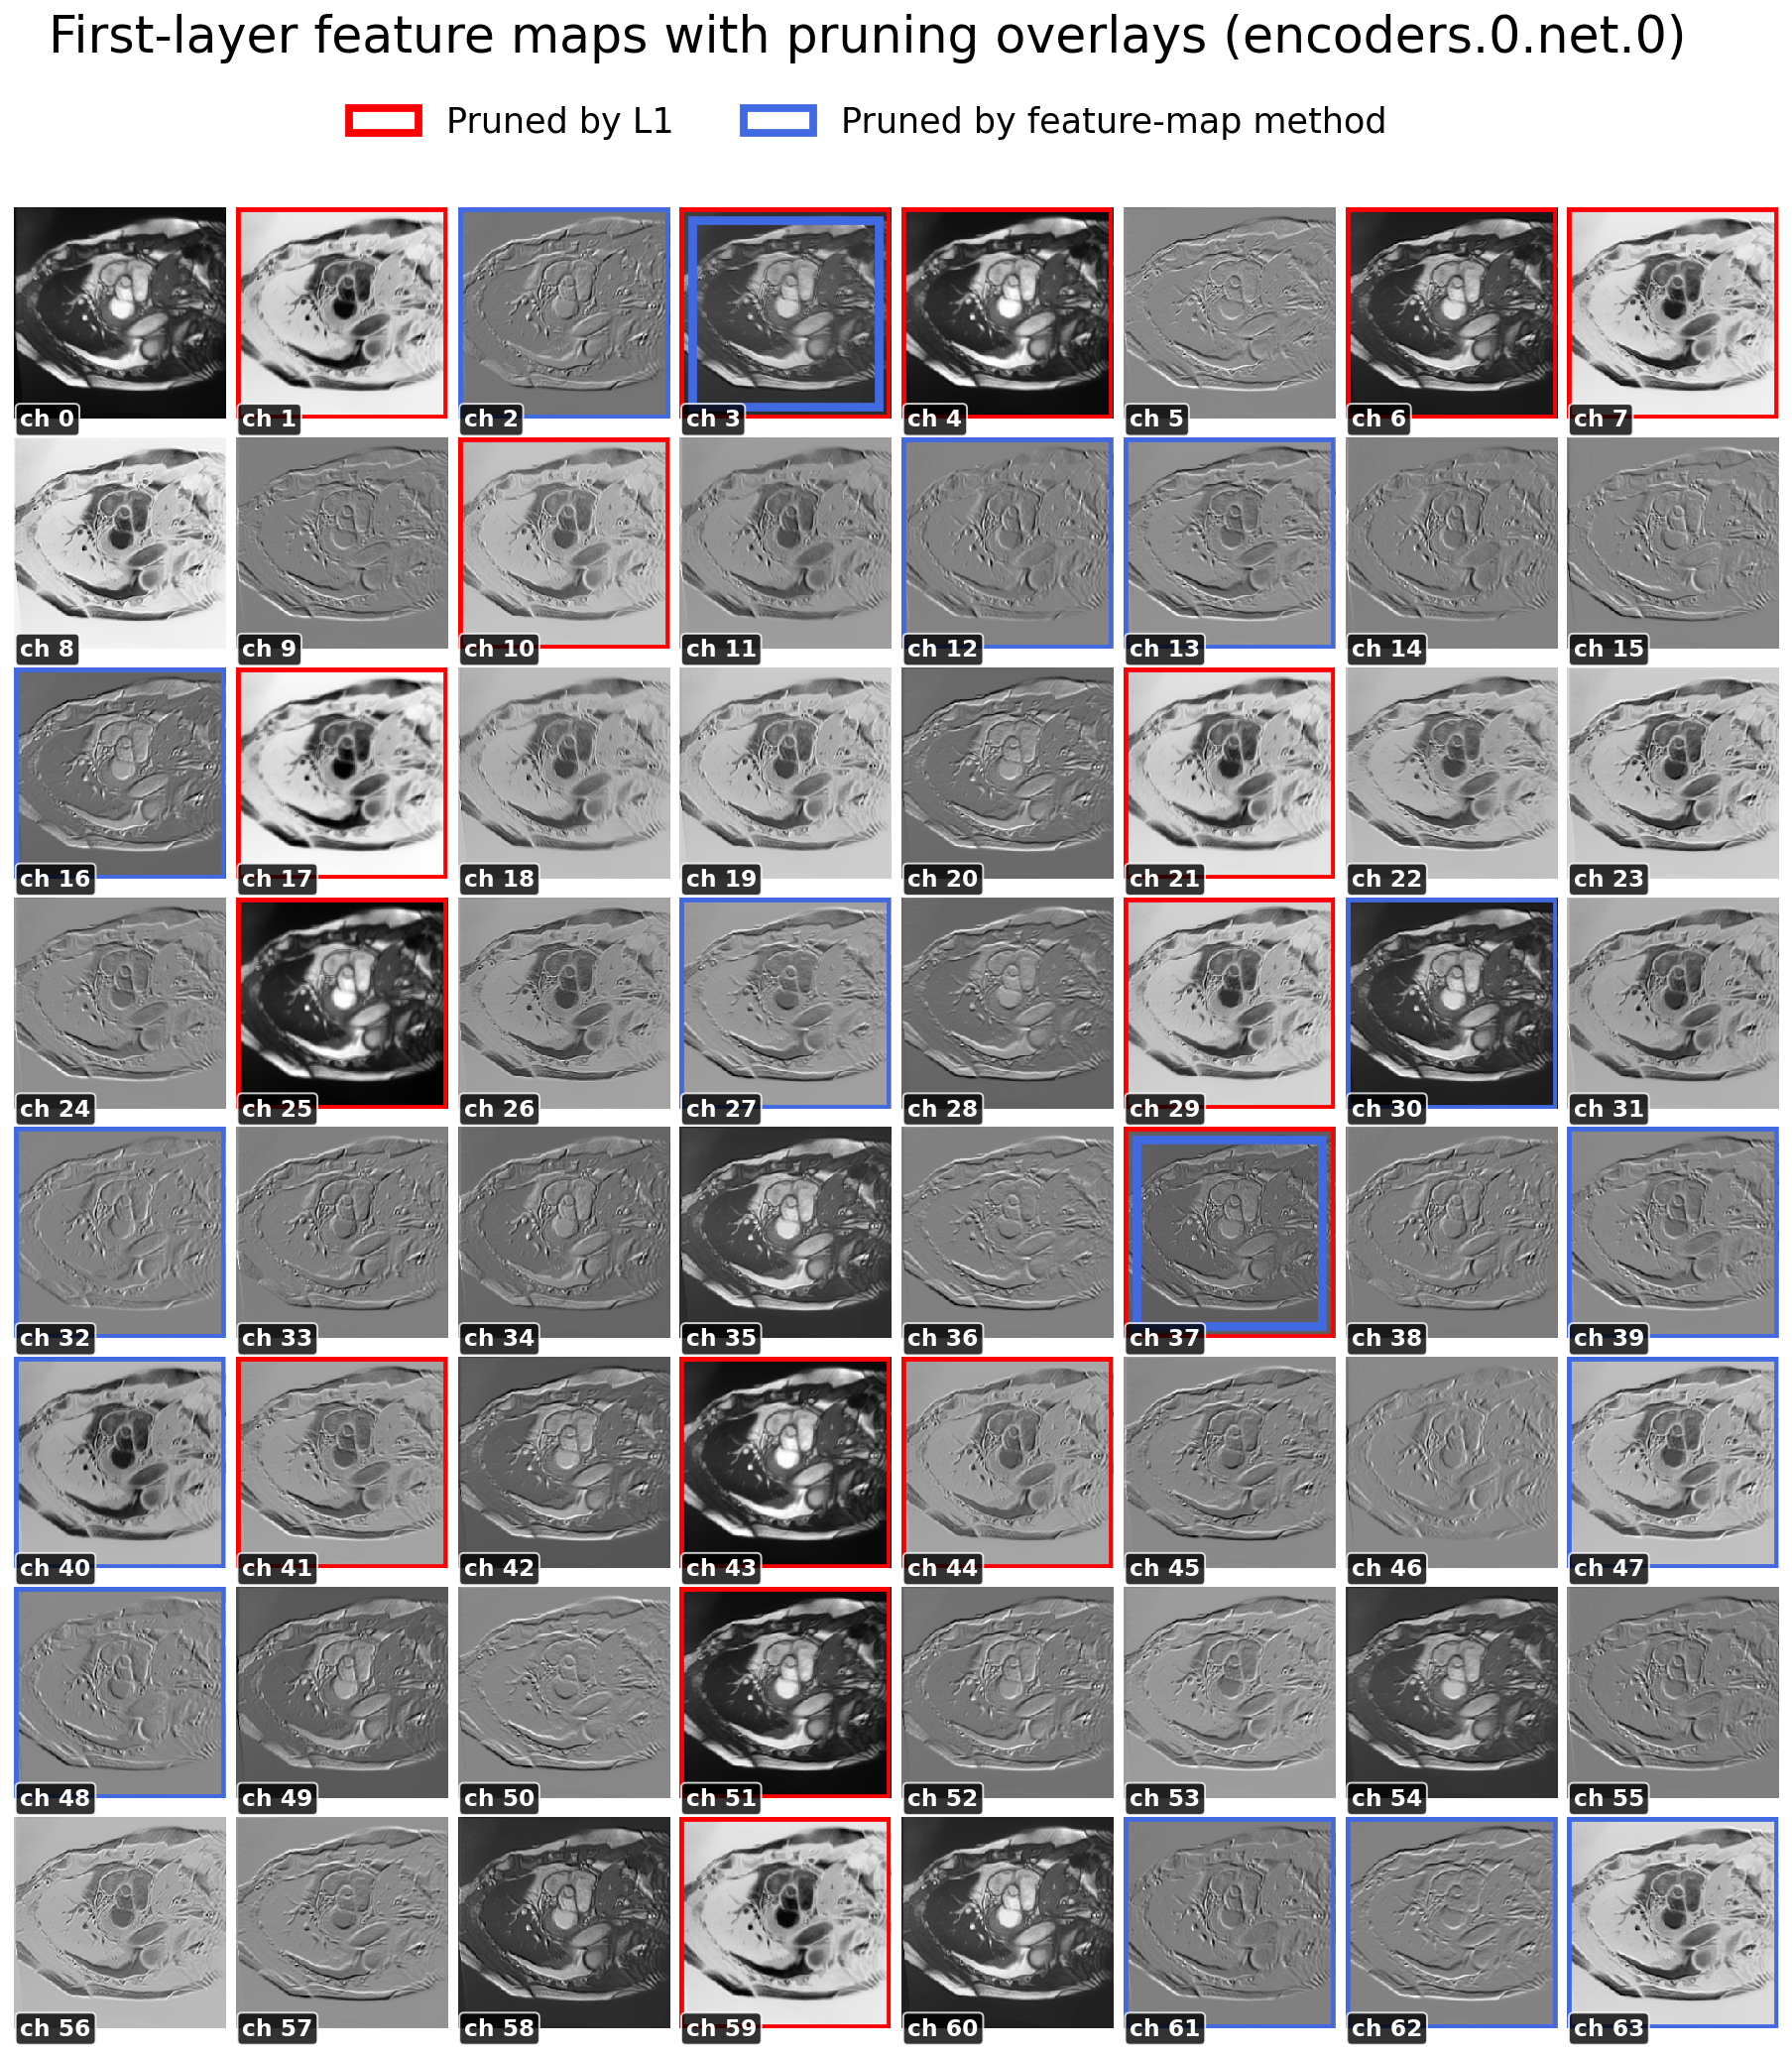

In [8]:
plot_first_layer_grid(
    feature_maps=feature_maps,
    l1_keep=l1_keep,
    fm_keep=fm_keep,
    num_cols=num_cols,
    normalize=normalize_each_channel,
)